# Carga de df y construccion dataset

In [ ]:
import pandas as pd

# DataFrames RAW

df_popolazione_raw = pd.read_excel(
    "popolazioneRegioni2025.xlsx",
    skiprows=1
)
df_superficie_raw = pd.read_excel("superficieRegioni2025.xlsx")

df_disoccupazione_raw = pd.read_excel("tassoDisoccupazioneRegioni2025.xlsx")

df_pil_pro_capite_raw = pd.read_excel("pilProCapitaleRegioni2024.xlsx")

df_reddito_medio_raw = pd.read_excel("redittoMedioPrpAbitante2024Regioni.xlsx")

df_indice_dipendenza_raw = pd.read_excel("indiceDipendenzaRegioni2025Regioni.xlsx")

df_percentuale_over65_raw = pd.read_excel("percentualePopolazione65AnniPiu2025Regioni.xlsx")

df_speranza_vita_raw = pd.read_excel("speranzaVitaRegioni2025.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [ ]:
display(df_popolazione_raw.head())

display(df_superficie_raw.head())

display(df_disoccupazione_raw.head())

display(df_pil_pro_capite_raw.head())

display(df_reddito_medio_raw.head())

display(df_indice_dipendenza_raw.head())

display(df_percentuale_over65_raw.head())

display(df_speranza_vita_raw.head())

,Codice regione,Regione,Età,Totale
0,13,Abruzzo,0,7374
1,13,Abruzzo,1,7650
2,13,Abruzzo,2,8158
3,13,Abruzzo,3,8461
4,13,Abruzzo,4,8639


,Regione,Nome,Superficie
0,01 Piemonte,Piemonte,25387.0691
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta,3260.8981
2,03 Lombardia,Lombardia,23863.6514
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige,13605.5008
4,05 Veneto,Veneto,18407.4157


,Regione,Nome,Tasso di disoccupazione
0,01 Piemonte,Piemonte,6.164193
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta / Vallée d'Aoste,3.914399
2,03 Lombardia,Lombardia,3.005698
3,04 Trentino-Alto Adige/Südtirol,Trentino Alto Adige / Südtirol,2.028590
4,05 Veneto,Veneto,3.506283


,Regione,Nome,PIL per capitale
0,01 Piemonte,Piemonte,38.625544
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta / Vallée d'Aoste,47.742769
2,03 Lombardia,Lombardia,50.398856
3,04 Trentino-Alto Adige/Südtirol,Provincia Autonoma Bolzano / Bozen,61.601948
4,05 Veneto,Veneto,41.496314


,Regione,Nome,Reddito medio per abitante
0,01 Piemonte,Piemonte,25426.324168
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta / Vallée d'Aoste,25750.976125
2,03 Lombardia,Lombardia,28154.290650
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige/Südtirol,26052.348322
4,05 Veneto,Veneto,24652.277887


,Regione,Nome,Indice di dipendenza strutturale
0,01 Piemonte,Piemonte,61.5
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta,59.2
2,03 Lombardia,Lombardia,56.4
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige,57.4
4,05 Veneto,Veneto,57.9


,Regione,Nome,% 65 anni e oltre
0,01 Piemonte,Piemonte,26.9
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta,25.8
2,03 Lombardia,Lombardia,23.8
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige,22.5
4,05 Veneto,Veneto,24.9


,Regione,Nome,Speranza di vita alla nascita
0,01 Piemonte,Piemonte,83.6
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta,83.7
2,03 Lombardia,Lombardia,84.3
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige,84.8
4,05 Veneto,Veneto,84.4


In [ ]:
# Copia del raw
df_popolazione = df_popolazione_raw.copy()

# Quedarnos solo con el total de población
df_popolazione = df_popolazione[df_popolazione["Età"] == 999].copy()

# Guardamos el nombre de la región antes de modificarlo
df_popolazione["Nome"] = df_popolazione["Regione"]

# Construimos la columna Región con código + nombre
df_popolazione["Regione"] = (
    df_popolazione["Codice regione"].astype(int).astype(str).str.zfill(2)
    + " "
    + df_popolazione["Regione"]
)

# Renombramos la columna de población
df_popolazione = df_popolazione.rename(columns={"Totale": "Popolazione"})

# Nos quedamos solo con las columnas finales
df_popolazione = df_popolazione[
    ["Regione", "Nome", "Popolazione"]
].reset_index(drop=True)

display(df_popolazione.head())

,Regione,Nome,Popolazione
0,13 Abruzzo,Abruzzo,1269118
1,17 Basilicata,Basilicata,530004
2,18 Calabria,Calabria,1834646
3,15 Campania,Campania,5582337
4,08 Emilia-Romagna,Emilia-Romagna,4461998


In [ ]:
# Quitar espacios en los nombres de las columnas de TODOS los dataframes
for df in [
    df_superficie_raw,
    df_disoccupazione_raw,
    df_pil_pro_capite_raw,
    df_reddito_medio_raw,
    df_indice_dipendenza_raw,
    df_percentuale_over65_raw,
    df_speranza_vita_raw,
]:
    df.columns = df.columns.str.strip()

In [ ]:
df_superficie_raw = df_superficie_raw.drop(columns="Nome")
df_disoccupazione_raw = df_disoccupazione_raw.drop(columns="Nome")
df_pil_pro_capite_raw = df_pil_pro_capite_raw.drop(columns="Nome")
df_reddito_medio_raw = df_reddito_medio_raw.drop(columns="Nome")
df_indice_dipendenza_raw = df_indice_dipendenza_raw.drop(columns="Nome")
df_percentuale_over65_raw = df_percentuale_over65_raw.drop(columns="Nome")
df_speranza_vita_raw = df_speranza_vita_raw.drop(columns="Nome")

In [ ]:
print(df_superficie_raw.columns.tolist())
print(df_disoccupazione_raw.columns.tolist())
print(df_pil_pro_capite_raw.columns.tolist())
print(df_reddito_medio_raw.columns.tolist())
print(df_indice_dipendenza_raw.columns.tolist())
print(df_percentuale_over65_raw.columns.tolist())
print(df_speranza_vita_raw.columns.tolist())

['Regione', 'Superficie']
['Regione', 'Tasso di disoccupazione']
['Regione', 'PIL per capitale']
['Regione', 'Reddito medio per abitante']
['Regione', 'Indice di dipendenza strutturale']
['Regione', '% 65 anni e oltre']
['Regione', 'Speranza di vita alla nascita']


In [ ]:
df_italia = df_popolazione.copy()

df_italia = df_italia.merge(df_superficie_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_disoccupazione_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_pil_pro_capite_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_reddito_medio_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_indice_dipendenza_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_percentuale_over65_raw, on="Regione", how="inner")
df_italia = df_italia.merge(df_speranza_vita_raw, on="Regione", how="inner")

display(df_italia)

,Regione,Nome,Popolazione,Superficie,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita
0,13 Abruzzo,Abruzzo,1269118,10831.838800,6.762283,32.108655,20310.124110,60.0,26.1,83.7
1,17 Basilicata,Basilicata,530004,10073.322600,5.510016,28.416266,17816.107245,58.2,26.0,83.1
2,18 Calabria,Calabria,1834646,15221.902100,10.210476,21.702179,16795.945911,58.5,24.5,82.9
3,15 Campania,Campania,5582337,13670.947700,14.251343,24.564171,17177.123212,53.0,21.4,82.1
4,08 Emilia-Romagna,Emilia-Romagna,4461998,22452.777900,4.158524,44.557018,26683.839083,58.0,24.9,84.2
5,06 Friuli-Venezia Giulia,Friuli-Venezia Giulia,1193284,7862.302400,4.684697,39.005129,24780.922684,62.3,27.5,84.1
6,12 Lazio,Lazio,5709178,17232.290600,5.680821,43.166916,24436.737502,55.6,23.8,83.6
7,07 Liguria,Liguria,1510143,5416.213500,4.710665,38.841814,25503.555194,65.3,29.2,83.7
8,03 Lombardia,Lombardia,10033918,23863.651400,3.005698,50.398856,28154.290650,56.4,23.8,84.3
9,11 Marche,Marche,1480545,9401.375500,5.290068,34.149106,22489.256780,61.0,26.6,84.4


In [ ]:
# Convertir el PIB per cápita de miles de euros a euros
df_italia["PIL per capitale"] = df_italia["PIL per capitale"] * 1000

# Calcular la densidad de población (hab/km²)
df_italia["Densità di popolazione"] = (
    df_italia["Popolazione"] / df_italia["Superficie"]
)

# Redondear columnas a 2 decimales
columnas_redondear = [
    "Superficie",
    "Densità di popolazione",
    "Tasso di disoccupazione",
    "PIL per capitale",
    "Reddito medio per abitante"
]

df_italia[columnas_redondear] = df_italia[columnas_redondear].round(2)

# Ordenar por código de región
df_italia = df_italia.sort_values("Regione").reset_index(drop=True)

display(df_italia)

,Regione,Nome,Popolazione,Superficie,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
0,01 Piemonte,Piemonte,4251868,25387.07,6.16,38625.54,25426.32,61.5,26.9,83.6,167.48
1,02 Valle d'Aosta/Vallée d'Aoste,Valle d'Aosta/Vallée d'Aoste,122532,3260.90,3.91,47742.77,25750.98,59.2,25.8,83.7,37.58
2,03 Lombardia,Lombardia,10033918,23863.65,3.01,50398.86,28154.29,56.4,23.8,84.3,420.47
3,04 Trentino-Alto Adige/Südtirol,Trentino-Alto Adige/Südtirol,1086252,13605.50,2.03,61601.95,26052.35,57.4,22.5,84.8,79.84
4,05 Veneto,Veneto,4853472,18407.42,3.51,41496.31,24652.28,57.9,24.9,84.4,263.67
5,06 Friuli-Venezia Giulia,Friuli-Venezia Giulia,1193284,7862.30,4.68,39005.13,24780.92,62.3,27.5,84.1,151.77
6,07 Liguria,Liguria,1510143,5416.21,4.71,38841.81,25503.56,65.3,29.2,83.7,278.82
7,08 Emilia-Romagna,Emilia-Romagna,4461998,22452.78,4.16,44557.02,26683.84,58.0,24.9,84.2,198.73
8,09 Toscana,Toscana,3657716,22987.04,4.39,39262.01,24495.76,60.7,26.8,84.3,159.12
9,10 Umbria,Umbria,851473,8464.33,4.65,32466.90,22523.94,62.5,27.4,84.1,100.60


In [ ]:
df_italia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Regione                           20 non-null     object 
 1   Nome                              20 non-null     object 
 2   Popolazione                       20 non-null     int64  
 3   Superficie                        20 non-null     float64
 4   Tasso di disoccupazione           20 non-null     float64
 5   PIL per capitale                  20 non-null     float64
 6   Reddito medio per abitante        20 non-null     float64
 7   Indice di dipendenza strutturale  20 non-null     float64
 8   % 65 anni e oltre                 20 non-null     float64
 9   Speranza di vita alla nascita     20 non-null     float64
 10  Densità di popolazione            20 non-null     float64
dtypes: float64(8), int64(1), object(2)
memory usage: 1.8+ KB


# Transformaciones

Se ha realizado la misma metodología que con el dataset español.

- Con el objetivo de sintetizar la información contenida en las variables socioeconómicas y demográficas, se aplicó un Análisis de Componentes Principales (PCA) sobre el conjunto de datos normalizado.
- Posteriormente, se empleó el algoritmo K-Means para identificar posibles tipologías territoriales entre las regiones italianas y analizar si los patrones obtenidos son coherentes con la estructura territorial descrita por la literatura sobre la *Questione Meridionale.*
- Se representan los clusters generados gráficamente

In [ ]:
df_italia.info()
df_italia.describe()
df_italia.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Regione                           20 non-null     object 
 1   Nome                              20 non-null     object 
 2   Popolazione                       20 non-null     int64  
 3   Superficie                        20 non-null     float64
 4   Tasso di disoccupazione           20 non-null     float64
 5   PIL per capitale                  20 non-null     float64
 6   Reddito medio per abitante        20 non-null     float64
 7   Indice di dipendenza strutturale  20 non-null     float64
 8   % 65 anni e oltre                 20 non-null     float64
 9   Speranza di vita alla nascita     20 non-null     float64
 10  Densità di popolazione            20 non-null     float64
dtypes: float64(8), int64(1), object(2)
memory usage: 1.8+ KB


,0
Regione,0
Nome,0
Popolazione,0
Superficie,0
Tasso di disoccupazione,0
PIL per capitale,0
Reddito medio per abitante,0
Indice di dipendenza strutturale,0
% 65 anni e oltre,0
Speranza di vita alla nascita,0


In [ ]:
df = df_italia.copy()

Las variables como superficie y población se descartan para el modelo debido a su dimensionalidad y su importancia analítica.

In [ ]:
# Variables descriptivas
cols_descriptivas = [
    "Popolazione",
    "Superficie",
    "Densità di popolazione",
    "Tasso di disoccupazione",
    "PIL per capitale",
    "Reddito medio per abitante",
    "Indice di dipendenza strutturale",
    "% 65 anni e oltre",
    "Speranza di vita alla nascita"
]

# Variables para PCA y clustering
cols_modelo = [
    "Tasso di disoccupazione",
    "PIL per capitale",
    "Reddito medio per abitante",
    "Indice di dipendenza strutturale",
    "% 65 anni e oltre",
    "Speranza di vita alla nascita",
    "Densità di popolazione"
]

df_desc = df[cols_descriptivas].copy()
df_modelo = df[cols_modelo].copy()

Como primer paso se realizó un análisis descriptivo de las variables incluidas en el estudio. Este análisis permite conocer la distribución general de los indicadores considerados y detectar posibles diferencias entre las regiones italianas antes de aplicar las técnicas multivariantes.

Al igual que en el caso español mostramos cuartiles y media

In [ ]:
resumen = df_desc.describe().T
display(resumen)

,count,mean,std,min,25%,50%,75%,max
Popolazione,20.0,2.947173e+06,2.504670e+06,122532.00,1.166526e+06,1698513.500,4.543346e+06,10033918.00
Superficie,20.0,1.510364e+04,7.448375e+03,3260.90,9.167118e+03,14446.425,2.258635e+04,25832.39
Densità di popolazione,20.0,1.779310e+02,1.121765e+02,37.58,9.541000e+01,158.300,2.149650e+02,420.47
Tasso di disoccupazione,20.0,6.377500e+00,3.274109e+00,2.03,4.332500e+00,5.400,7.452500e+00,14.25
PIL per capitale,20.0,3.605853e+04,1.038328e+04,21702.18,2.772258e+04,36387.325,4.191396e+04,61601.95
Reddito medio per abitante,20.0,2.234403e+04,3.725841e+03,16795.95,1.847082e+04,23480.340,2.544563e+04,28154.29
Indice di dipendenza strutturale,20.0,5.912500e+01,2.745307e+00,53.00,5.760000e+01,58.850,6.077500e+01,65.30
% 65 anni e oltre,20.0,2.556500e+01,1.935887e+00,21.40,2.432500e+01,25.900,2.700000e+01,29.20
Speranza di vita alla nascita,20.0,8.364000e+01,7.184779e-01,82.10,8.310000e+01,83.700,8.422500e+01,84.80


Para obtener una primera visión a las diferencias territoriales, se elaboraron rankings de las regiones con los valores más elevados y más reducidos en los principales indicadores socioeconómicos analizados, concretamente el PIB per cápita, la tasa de desempleo, la renta media por habitante y el porcentaje de población de 65 años o más.

In [ ]:
variables_ranking = [
    "PIL per capitale",
    "Tasso di disoccupazione",
    "Reddito medio per abitante",
    "% 65 anni e oltre"
]

for col in variables_ranking:
    print(f"\nTOP 5 {col}")
    display(df[["Nome", col]].sort_values(col, ascending=False).head())

    print(f"\nBOTTOM 5 {col}")
    display(df[["Nome", col]].sort_values(col).head())


TOP 5 PIL per capitale


,Nome,PIL per capitale
3,Trentino-Alto Adige/Südtirol,61601.95
2,Lombardia,50398.86
1,Valle d'Aosta/Vallée d'Aoste,47742.77
7,Emilia-Romagna,44557.02
11,Lazio,43166.92



BOTTOM 5 PIL per capitale


,Nome,PIL per capitale
17,Calabria,21702.18
18,Sicilia,23308.65
15,Puglia,24327.73
14,Campania,24564.17
13,Molise,27697.84



TOP 5 Tasso di disoccupazione


...

,Nome,Reddito medio per abitante
17,Calabria,16795.95
14,Campania,17177.12
18,Sicilia,17402.08
16,Basilicata,17816.11
15,Puglia,17897.67



TOP 5 % 65 anni e oltre


,Nome,% 65 anni e oltre
6,Liguria,29.2
5,Friuli-Venezia Giulia,27.5
19,Sardegna,27.5
9,Umbria,27.4
13,Molise,27.3



BOTTOM 5 % 65 anni e oltre


,Nome,% 65 anni e oltre
14,Campania,21.4
3,Trentino-Alto Adige/Südtirol,22.5
18,Sicilia,23.7
11,Lazio,23.8
2,Lombardia,23.8


Se calculó la matriz de correlaciones de Pearson con el objetivo de analizar la relación existente entre las variables utilizadas en el estudio. Este análisis exploratorio permite identificar asociaciones entre indicadores y comprobar la existencia de estructuras que posteriormente serán sintetizadas mediante el Análisis de Componentes Principales.

In [ ]:
corr = df_modelo.corr(method="pearson")
display(corr)

,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
Tasso di disoccupazione,1.000000,-0.814062,-0.822381,-0.390881,-0.322241,-0.842508,0.154543
PIL per capitale,-0.814062,1.000000,0.898256,0.010718,-0.123070,0.770010,0.109717
Reddito medio per abitante,-0.822381,0.898256,1.000000,0.246981,0.151595,0.797371,0.217939
Indice di dipendenza strutturale,-0.390881,0.010718,0.246981,1.000000,0.919487,0.299122,-0.430014
% 65 anni e oltre,-0.322241,-0.123070,0.151595,0.919487,1.000000,0.158853,-0.440809
Speranza di vita alla nascita,-0.842508,0.770010,0.797371,0.299122,0.158853,1.000000,-0.026393
Densità di popolazione,0.154543,0.109717,0.217939,-0.430014,-0.440809,-0.026393,1.000000


Como se puede observar:
- El paro esta fuertemente correlacionado de manera negativa con la esperanza de vida, la renta media por habitante y el pib per capita
- La esperanza de vida a su vez, esta fuertemente correlacionada con la renta y el pib per capita

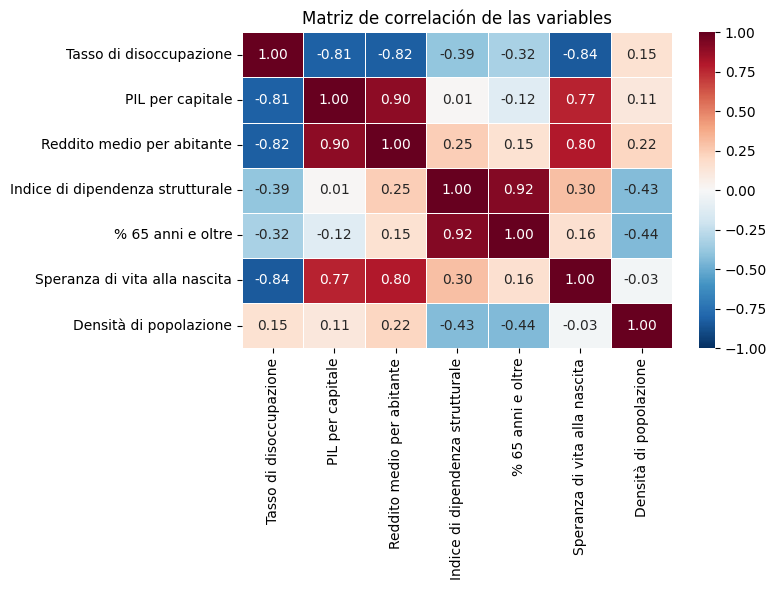

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables")
plt.tight_layout()
plt.show()

Se realiza una normalización de las variables para que todas sean comparables en la misma escala.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_modelo)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=cols_modelo,
    index=df["Nome"]
)

display(df_scaled)

,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
Nome,,,,,,,
Piemonte,-0.068156,0.253648,0.848764,0.887587,0.707521,-0.057120,-0.095586
Valle d'Aosta/Vallée d'Aoste,-0.773219,1.154527,0.938165,0.028029,0.124545,0.085679,-1.283666
Lombardia,-1.055244,1.416977,1.599960,-1.018389,-0.935412,0.942473,2.218289
Trentino-Alto Adige/Südtirol,-1.362337,2.523962,1.021153,-0.644668,-1.624384,1.656467,-0.897151
Veneto,-0.898563,0.537310,0.635618,-0.457808,-0.352436,1.085271,0.784178
Friuli-Venezia Giulia,-0.531930,0.291155,0.671041,1.186564,1.025508,0.656875,-0.239271
Liguria,-0.522530,0.275017,0.870033,2.307726,1.926472,0.085679,0.922742
Emilia-Romagna,-0.694878,0.839741,1.195045,-0.420436,-0.352436,0.799674,0.190230
Toscana,-0.622805,0.316538,0.592517,0.588610,0.654523,0.942473,-0.172048


## Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales (PCA) se aplicó sobre las variables previamente estandarizadas con el objetivo de reducir la dimensionalidad del conjunto de datos, conservando la mayor parte de la información original. Esta técnica permite identificar los principales ejes de variación que caracterizan las diferencias socioeconómicas entre las regiones italianas.

La siguiente tabla muestra la proporción de varianza explicada por cada componente principal, así como la varianza acumulada. Estos resultados permiten determinar el número de componentes necesarios para representar adecuadamente la estructura de los datos.

Al igual que en el caso español, con solo 2 componentes principales podemos explicar más del 80% del conjunto

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(df_scaled)

varianza = pd.DataFrame({
    "Componente":[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza_explicada":pca.explained_variance_ratio_,
    "Varianza_acumulada":pca.explained_variance_ratio_.cumsum()
})

display(varianza)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.520533,0.520533
1,PC2,0.314792,0.835325
2,PC3,0.103621,0.938945
3,PC4,0.031925,0.970870
4,PC5,0.017263,0.988133
5,PC6,0.009241,0.997374
6,PC7,0.002626,1.000000


La Figura siguiente representa la evolución de la varianza acumulada explicada por las componentes principales. Este gráfico facilita la selección del número de componentes más representativos del conjunto de datos.

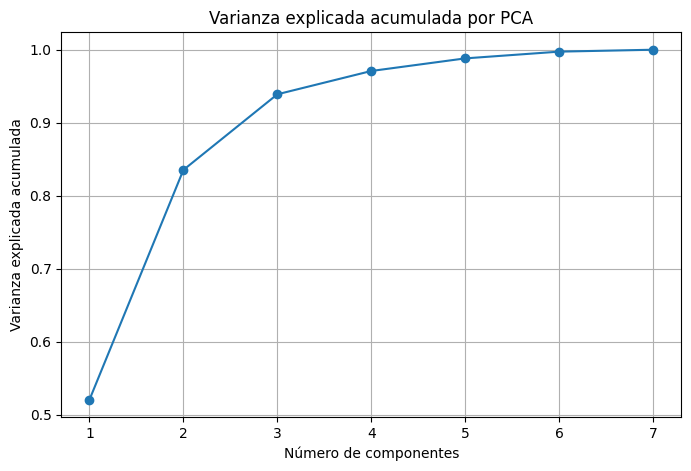

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.grid(True)
plt.show()

Una vez calculado el Análisis de Componentes Principales, cada región puede representarse mediante sus coordenadas sobre las dos primeras componentes principales (PC1 y PC2). Estas coordenadas no corresponden a variables originales, sino a nuevas dimensiones obtenidas como combinación lineal de los indicadores socioeconómicos y demográficos considerados.

Regiones con valores similares en ambas componentes presentan perfiles socioeconómicos parecidos, mientras que aquellas situadas en posiciones alejadas muestran características diferenciadas. La interpretación del significado de cada componente se realizará posteriormente a partir de las cargas (loadings) de las variables originales.

In [ ]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(df_scaled)

df_pca = pd.DataFrame({
    "Regione": df["Nome"],
    "PC1": X_pca_2[:,0],
    "PC2": X_pca_2[:,1]
})

display(df_pca)

,Regione,PC1,PC2
0,Piemonte,-0.885600,0.716058
1,Valle d'Aosta/Vallée d'Aoste,-1.481419,0.157209
2,Lombardia,-1.831971,-2.968600
3,Trentino-Alto Adige/Südtirol,-2.648831,-1.996213
4,Veneto,-1.287080,-1.212935
5,Friuli-Venezia Giulia,-1.527911,1.086939
6,Liguria,-1.734755,1.706196
7,Emilia-Romagna,-1.490502,-1.081857
8,Toscana,-1.459994,0.489444
9,Umbria,-0.978644,1.627944


La proyección de las regiones sobre las dos primeras componentes principales permite visualizar las similitudes y diferencias existentes entre ellas. Regiones con características socioeconómicas similares aparecen próximas entre sí, mientras que aquellas con perfiles diferenciados se sitúan más alejadas en el espacio factorial.

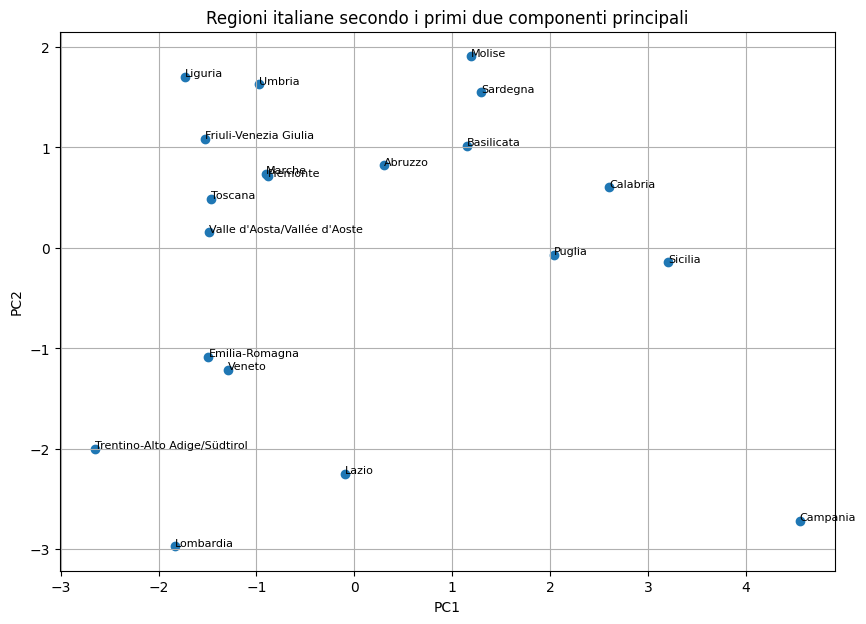

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(df_pca["PC1"], df_pca["PC2"])

for _, row in df_pca.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["Regione"],
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Regioni italiane secondo i primi due componenti principali")

plt.grid(True)

plt.show()

Las cargas (loadings) permiten interpretar el significado de cada componente principal al indicar la contribución de las variables originales a cada eje del PCA.

En este caso, la primera componente principal (PC1) está fuertemente asociada de forma positiva con la tasa de desempleo y de forma negativa con el PIB per cápita, la renta media por habitante y la esperanza de vida. Esto indica que PC1 representa principalmente un eje de vulnerabilidad socioeconómica, situando en un extremo las regiones con mejores indicadores económicos y sociales y, en el extremo opuesto, aquellas con mayores dificultades socioeconómicas.

Por su parte, la segunda componente principal (PC2) está dominada por el porcentaje de población de 65 años o más y el índice de dependencia estructural, mientras que la densidad de población presenta una contribución negativa. En consecuencia, esta componente puede interpretarse como un eje demográfico, que diferencia las regiones más envejecidas y con mayor dependencia de aquellas con una población relativamente más joven y una mayor concentración demográfica.

Esta interpretación facilita la comprensión de la distribución observada en el plano factorial y permite analizar posteriormente la formación de los distintos grupos regionales obtenidos mediante el algoritmo K-Means.

In [ ]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1","PC2"],
    index=cols_modelo
)

display(loadings.sort_values("PC1", ascending=False))

,PC1,PC2
Tasso di disoccupazione,0.499266,0.002913
Densità di popolazione,0.048015,-0.469707
% 65 anni e oltre,-0.190277,0.585472
Indice di dipendenza strutturale,-0.247882,0.549313
PIL per capitale,-0.444434,-0.300816
Speranza di vita alla nascita,-0.473006,-0.094945
Reddito medio per abitante,-0.479083,-0.187990


El biplot combina la representación de las regiones con los vectores asociados a las variables originales. La dirección y longitud de cada vector permiten interpretar la contribución de las variables a cada componente principal y comprender los factores que explican la distribución observada de las regiones.

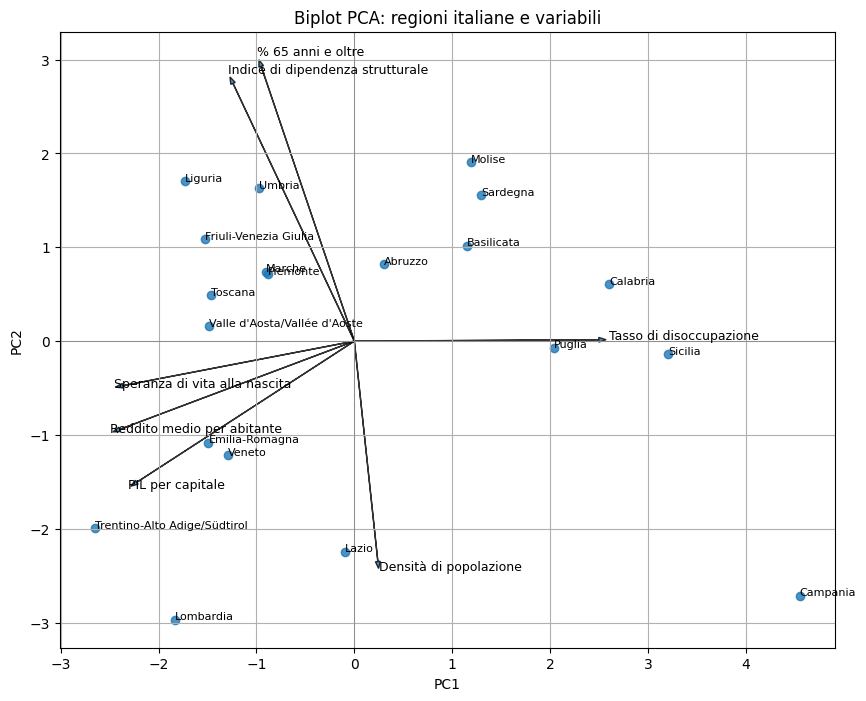

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

# Regiones
ax.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.8
)

for _, row in df_pca.iterrows():
    ax.text(
        row["PC1"],
        row["PC2"],
        row["Regione"],
        fontsize=8
    )

# Flechas variables
for variable in loadings.index:
    ax.arrow(
        0,
        0,
        loadings.loc[variable, "PC1"] * 5,
        loadings.loc[variable, "PC2"] * 5,
        head_width=0.05,
        alpha=0.8
    )

    ax.text(
        loadings.loc[variable, "PC1"] * 5.2,
        loadings.loc[variable, "PC2"] * 5.2,
        variable,
        fontsize=9
    )

ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Biplot PCA: regioni italiane e variabili")

plt.grid(True)
plt.show()

Con objeto de determinar el número más adecuado de agrupamientos, se evaluó el algoritmo K-Means para distintos valores de k. Como criterio de evaluación se empleó el índice de Silhouette, que mide simultáneamente la cohesión interna y la separación entre los distintos grupos obtenidos.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_k = []

for k in range(2,7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(
        df_scaled,
        labels
    )

    resultados_k.append({
        "k":k,
        "silhouette":score
    })

df_k = pd.DataFrame(resultados_k)

display(df_k)

,k,silhouette
0,2,0.352848
1,3,0.334704
2,4,0.333192
3,5,0.334554
4,6,0.337565


La Figura siguiente muestra la evolución del índice de Silhouette para diferentes valores del número de clusters. Este criterio proporciona una referencia cuantitativa para seleccionar la partición más adecuada, si bien la interpretación territorial de los resultados también constituye un aspecto relevante en la elección final.

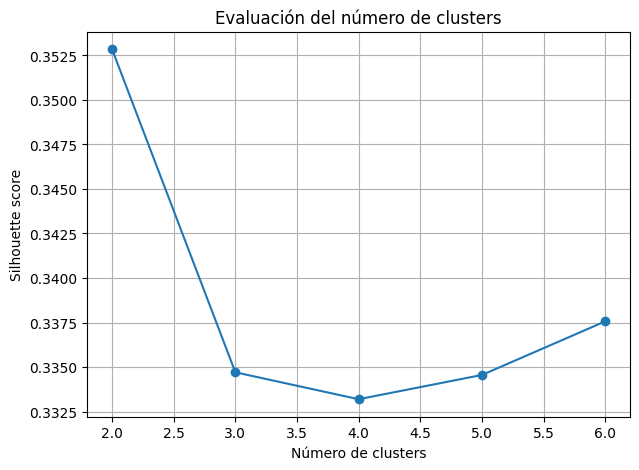

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    df_k["k"],
    df_k["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación del número de clusters")

plt.grid(True)
plt.show()

Según nos indica la tabla, el número óptimo de clusters es de 2. Pero realizamos una comparación para 3 y 4 también para observar algun que otro patrón territorial objeto de estudio.

In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(df_pca, df, columna_cluster, titulo):
    plt.figure(figsize=(10,8))

    plt.scatter(
        df_pca["PC1"],
        df_pca["PC2"],
        c=df[columna_cluster],
        cmap="tab10",
        s=90
    )

    for _, row in df_pca.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Regione"],
            fontsize=8
        )

    plt.axhline(0, color="gray", linewidth=0.5)
    plt.axvline(0, color="gray", linewidth=0.5)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(titulo)

    plt.grid(True)
    plt.show()

In [ ]:
for k in [2, 3, 4]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df[f"Cluster{k}"] = kmeans.fit_predict(df_scaled)

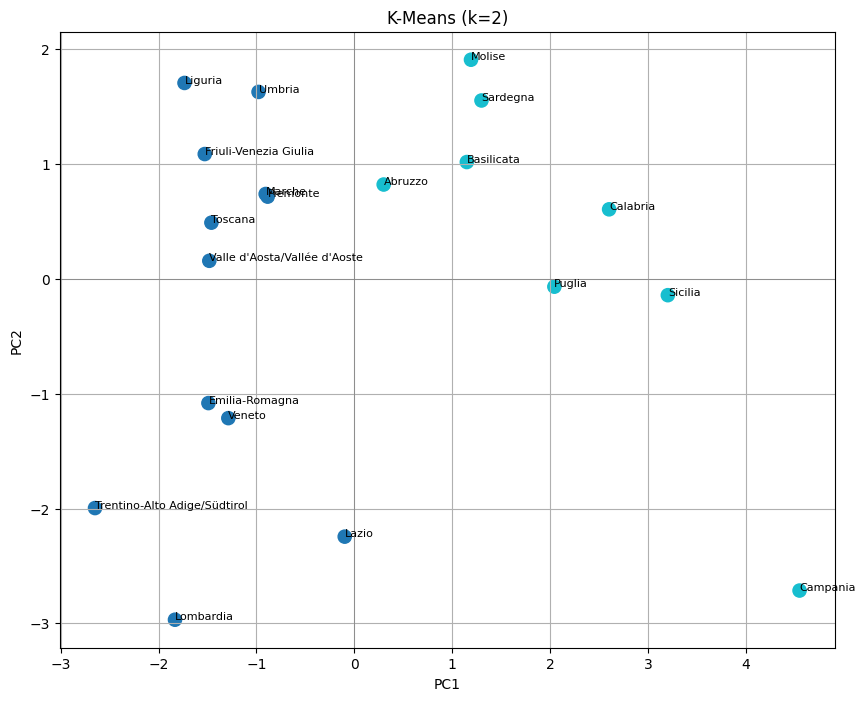

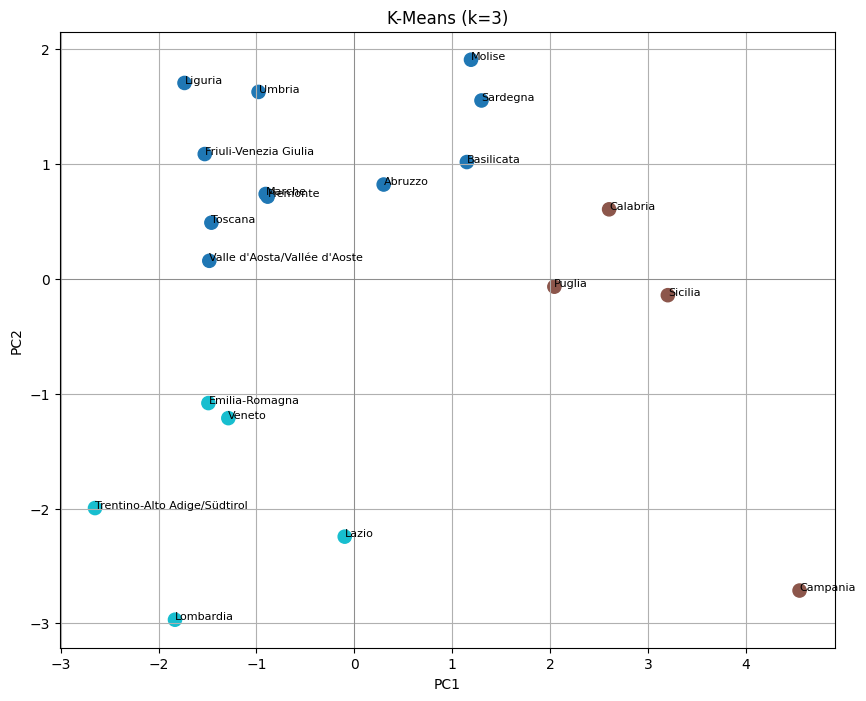

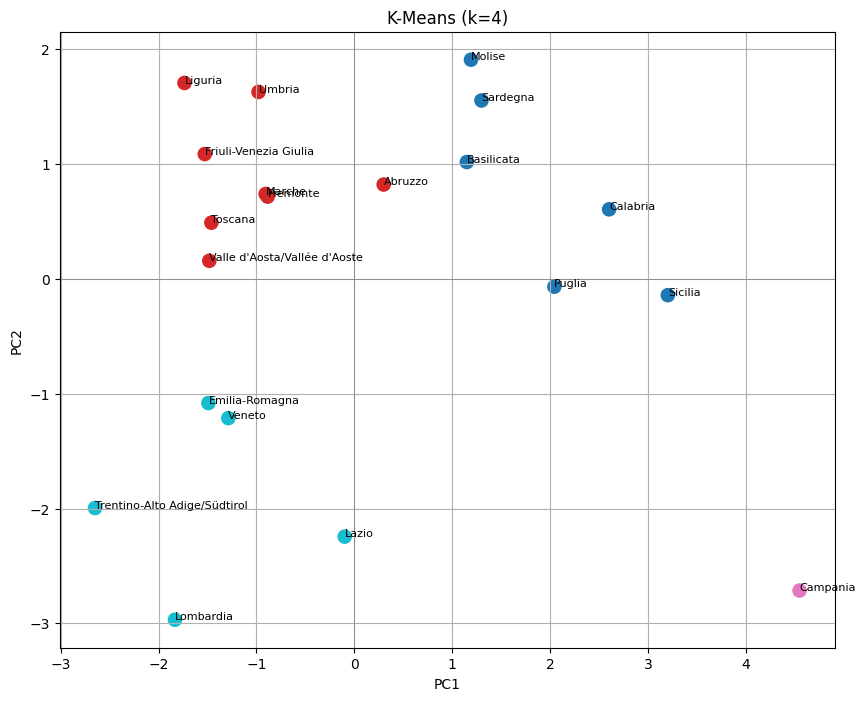

In [ ]:
plot_clusters(df_pca, df, "Cluster2", "K-Means (k=2)")
plot_clusters(df_pca, df, "Cluster3", "K-Means (k=3)")
plot_clusters(df_pca, df, "Cluster4", "K-Means (k=4)")

Una vez obtenido el agrupamiento, se calcularon los valores medios de cada variable dentro de cada cluster con el objetivo de caracterizar el perfil socioeconómico de los distintos grupos de regiones identificados.

In [ ]:
perfil2 = df.groupby("Cluster2")[cols_modelo].mean().round(2)
display(perfil2)

,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
Cluster2,,,,,,,
0,4.35,42609.53,25079.19,59.82,25.84,84.10,195.57
1,9.42,26232.04,18241.30,58.09,25.15,82.95,151.47


In [ ]:
perfil3 = df.groupby("Cluster3")[cols_modelo].mean().round(2)
display(perfil3)

,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
Cluster3,,,,,,,
0,5.63,35095.17,22511.67,60.95,27.01,83.67,122.91
1,11.80,23475.68,17318.21,56.68,23.58,82.78,228.16
2,3.68,48244.21,25995.90,57.06,23.98,84.26,258.80


In [ ]:
perfil4 = df.groupby("Cluster4")[cols_modelo].mean().round(2)
display(perfil4)

,Tasso di disoccupazione,PIL per capitale,Reddito medio per abitante,Indice di dipendenza strutturale,% 65 anni e oltre,Speranza di vita alla nascita,Densità di popolazione
Cluster4,,,,,,,
0,9.06,25530.58,18073.87,58.62,25.62,82.97,114.37
1,5.07,37775.24,23910.11,61.56,27.04,83.95,146.25
2,14.25,24564.17,17177.12,53.00,21.40,82.10,408.34
3,3.68,48244.21,25995.90,57.06,23.98,84.26,258.80


## Representación gráfica de clusters

Al igual que en el caso español se hace uso de la libreria geopandas y de los mapas proporcionados por el repositorio de código abierto de "code for germany"

In [ ]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/italy-regions.geojson"

gdf = gpd.read_file(url)

gdf.head()

,name,cartodb_id,created_at,updated_at,geometry
0,Piemonte,1,2013-11-28 03:00:02+01:00,2013-11-28 03:01:56+01:00,"MULTIPOLYGON (((8.45086 46.46268, 8.46285 46.4..."
1,Lombardia,3,2013-11-28 03:00:02+01:00,2013-11-28 03:01:56+01:00,"MULTIPOLYGON (((10.25036 46.61928, 10.25535 46..."
2,Trentino-Alto Adige/Sudtirol,4,2013-11-28 03:00:02+01:00,2013-11-28 03:01:56+01:00,"MULTIPOLYGON (((12.20656 47.08723, 12.20769 47..."
3,Veneto,5,2013-11-28 03:00:02+01:00,2013-11-28 03:01:56+01:00,"MULTIPOLYGON (((12.50691 46.67926, 12.50703 46..."
4,Friuli Venezia Giulia,6,2013-11-28 03:00:02+01:00,2013-11-28 03:01:56+01:00,"MULTIPOLYGON (((13.53135 45.78882, 13.53206 45..."


In [ ]:
print(gdf.columns)

Index(['name', 'cartodb_id', 'created_at', 'updated_at', 'geometry'], dtype='object')


In [ ]:
gdf["name"]

,name
0,Piemonte
1,Lombardia
2,Trentino-Alto Adige/Sudtirol
3,Veneto
4,Friuli Venezia Giulia
5,Liguria
6,Emilia-Romagna
7,Toscana
8,Umbria
9,Marche


In [ ]:
cluster_df = df[["Nome", "Cluster2"]].copy()
cluster_df = cluster_df.rename(columns={"Nome":"Mapa"})

Realizamos la correspodencia entre los nombres de las regiones en el repositorio y en el dataset. Las cuales son mínimas

In [ ]:
sorted(gdf["name"].unique())

['Abruzzo',
 'Basilicata',
 'Calabria',
 'Campania',
 'Emilia-Romagna',
 'Friuli Venezia Giulia',
 'Lazio',
 'Liguria',
 'Lombardia',
 'Marche',
 'Molise',
 'Piemonte',
 'Puglia',
 'Sardegna',
 'Sicilia',
 'Toscana',
 'Trentino-Alto Adige/Sudtirol',
 'Umbria',
 "Valle D'Aosta/Vallée D'Aoste",
 'Veneto']

In [ ]:
sorted(cluster_df["Mapa"].unique())

['Abruzzo',
 'Basilicata',
 'Calabria',
 'Campania',
 'Emilia-Romagna',
 'Friuli-Venezia Giulia',
 'Lazio',
 'Liguria',
 'Lombardia',
 'Marche',
 'Molise',
 'Piemonte',
 'Puglia',
 'Sardegna',
 'Sicilia',
 'Toscana',
 'Trentino-Alto Adige/Südtirol',
 'Umbria',
 "Valle d'Aosta/Vallée d'Aoste",
 'Veneto']

In [ ]:
cluster_df = df[["Nome", "Cluster2"]].copy()

cluster_df = cluster_df.rename(columns={"Nome": "Mapa"})

equivalencias = {
    "Friuli-Venezia Giulia": "Friuli Venezia Giulia",
    "Trentino-Alto Adige/Südtirol": "Trentino-Alto Adige/Sudtirol",
    "Valle d'Aosta/Vallée d'Aoste": "Valle D'Aosta/Vallée D'Aoste"
}

cluster_df["Mapa"] = cluster_df["Mapa"].replace(equivalencias)

gdf_merge = gdf.merge(
    cluster_df,
    left_on="name",
    right_on="Mapa",
    how="left"
)

### Representación del mapa de Italia para 2 clusters (óptimo)\

La partición en 2 clusters reproduce de forma muy clara la tradicional división territorial italiana entre el Centro-Norte y el *Mezzogiorno*.

El primer grupo agrupa prácticamente todas las regiones septentrionales y centrales, caracterizadas por mejores indicadores socioeconómicos, mientras que el segundo reúne las regiones del sur peninsular y las islas, donde se concentran mayores tasas de desempleo y menores niveles de renta y PIB per cápita.

Esta solución resulta coherente tanto con el análisis de componentes principales como con la literatura sobre la Questione Meridionale, constituyendo además la opción mejor valorada por el índice de Silhouette.

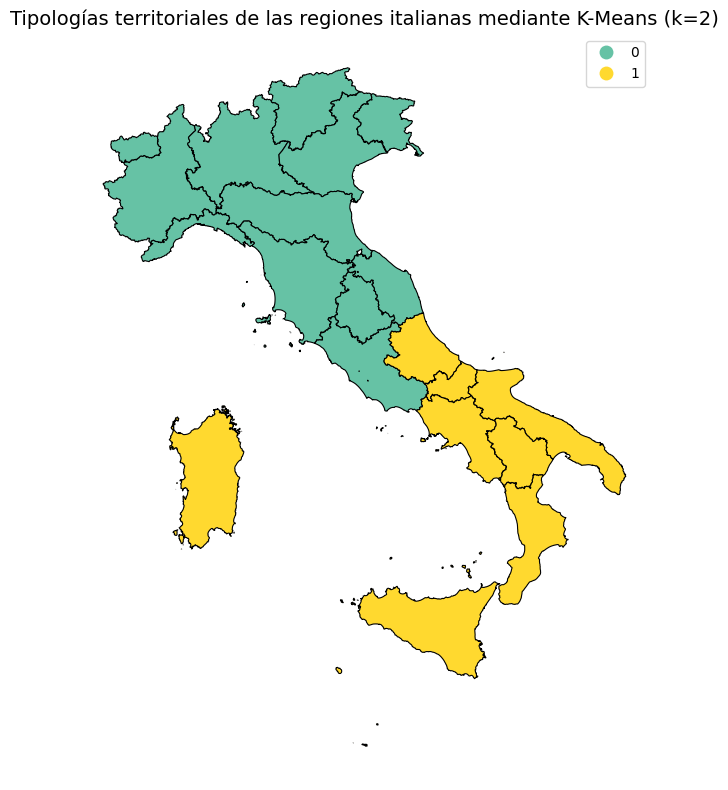

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Cluster 0 -> verde
# Cluster 1 -> azul
# Cluster 2 -> gris
# Cluster 3 -> amarillo
cmap = ListedColormap([
    "#66c2a5",
    "#8da0cb",
    "#bdbdbd",
    "#ffd92f"
])

fig, ax = plt.subplots(figsize=(10,8))

gdf_merge.plot(
    column="Cluster2",
    categorical=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title(
    "Tipologías territoriales de las regiones italianas mediante K-Means (k=2)",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

### Representación del mapa de Italia para 3 clusters

Al aumentar el número de clusters aparecen grupos adicionales que ya no responden de forma tan clara a una continuidad geográfica.

Algunas regiones del norte pasan a formar un grupo independiente, mientras que otras regiones centrales y meridionales quedan mezcladas en un mismo cluster.

Aunque esta solución refleja diferencias socioeconómicas más sutiles, su interpretación territorial resulta considerablemente menos intuitiva que la obtenida con k=2.

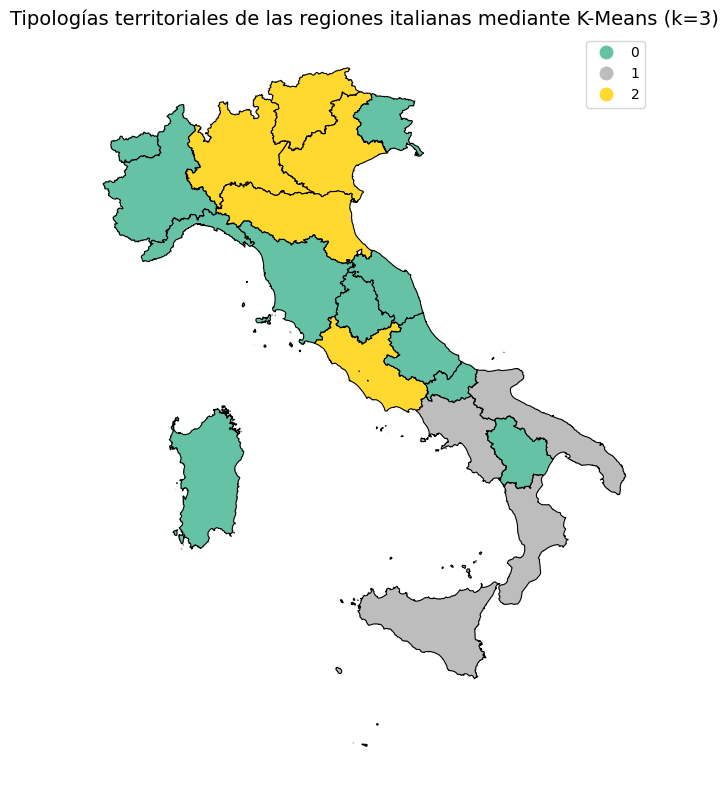

In [ ]:
cluster_df = df[["Nome", "Cluster3"]].copy()

cluster_df = cluster_df.rename(columns={"Nome": "Mapa"})

equivalencias = {
    "Friuli-Venezia Giulia": "Friuli Venezia Giulia",
    "Trentino-Alto Adige/Südtirol": "Trentino-Alto Adige/Sudtirol",
    "Valle d'Aosta/Vallée d'Aoste": "Valle D'Aosta/Vallée D'Aoste"
}

cluster_df["Mapa"] = cluster_df["Mapa"].replace(equivalencias)

gdf_merge = gdf.merge(
    cluster_df,
    left_on="name",
    right_on="Mapa",
    how="left"
)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "#66c2a5",  # Cluster 0
    "#8da0cb",  # Cluster 1
    "#bdbdbd",  # Cluster 2
    "#ffd92f"   # Cluster 3
])

fig, ax = plt.subplots(figsize=(10,8))

gdf_merge.plot(
    column="Cluster3",
    categorical=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title(
    "Tipologías territoriales de las regiones italianas mediante K-Means (k=3)",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

### Representación del mapa de Italia para 4 clusters

La partición en cuatro grupos incrementa aún más la fragmentación territorial. Algunos clusters quedan formados por un número reducido de regiones con características muy específicas, lo que dificulta la identificación de tipologías territoriales claramente diferenciadas. Si bien esta solución permite captar particularidades regionales, pierde capacidad de síntesis y genera agrupamientos menos fácilmente interpretables desde una perspectiva geográfica y socioeconómica.

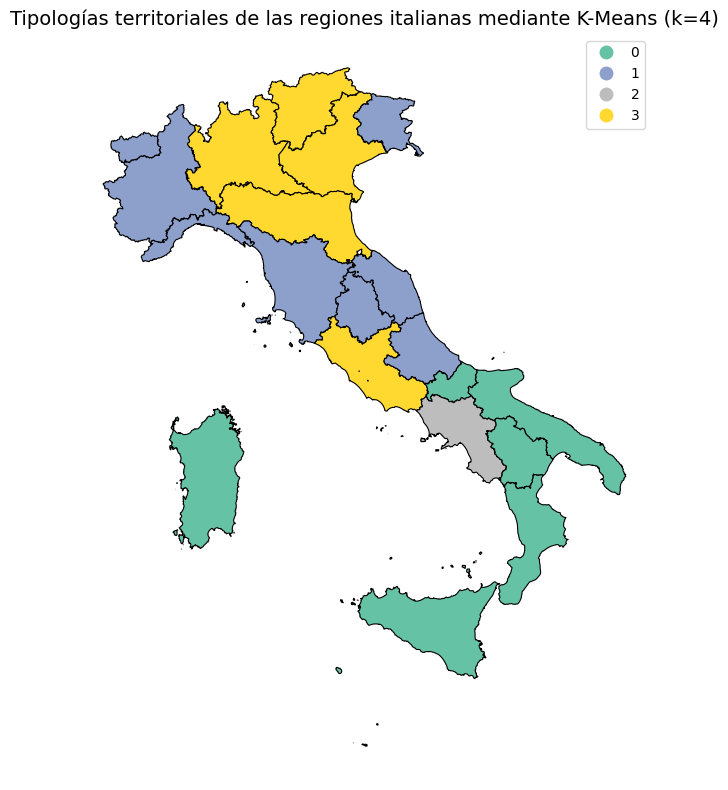

In [ ]:
cluster_df = df[["Nome", "Cluster4"]].copy()

cluster_df = cluster_df.rename(columns={"Nome": "Mapa"})

equivalencias = {
    "Friuli-Venezia Giulia": "Friuli Venezia Giulia",
    "Trentino-Alto Adige/Südtirol": "Trentino-Alto Adige/Sudtirol",
    "Valle d'Aosta/Vallée d'Aoste": "Valle D'Aosta/Vallée D'Aoste"
}

cluster_df["Mapa"] = cluster_df["Mapa"].replace(equivalencias)

gdf_merge = gdf.merge(
    cluster_df,
    left_on="name",
    right_on="Mapa",
    how="left"
)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "#66c2a5",  # Cluster 0
    "#8da0cb",  # Cluster 1
    "#bdbdbd",  # Cluster 2
    "#ffd92f"   # Cluster 3
])

fig, ax = plt.subplots(figsize=(10,8))

gdf_merge.plot(
    column="Cluster4",
    categorical=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title(
    "Tipologías territoriales de las regiones italianas mediante K-Means (k=4)",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

Los resultados obtenidos muestran que las dos primeras componentes principales explican más del 80 % de la variabilidad del conjunto de datos, permitiendo representar adecuadamente la estructura territorial italiana. El primer componente refleja principalmente un eje de vulnerabilidad socioeconómica, asociado a mayores niveles de desempleo frente a mayores niveles de renta, PIB per cápita y esperanza de vida, mientras que el segundo componente recoge principalmente diferencias demográficas relacionadas con el envejecimiento y la dependencia.

Asimismo, el análisis de agrupamiento identifica una clara diferenciación entre las regiones del Centro-Norte y las del Mezzogiorno, reproduciendo de forma consistente la tradicional división territorial descrita por la literatura italiana. Estos resultados servirán como base para el siguiente apartado, en el que se compararán los patrones obtenidos para España e Italia.